# Monte Carlo Study of Bias-Variance Tradeoff and Model Complexity
## Problem Statement
This project demonstrates the bias-variance tradeoff using polynomial regression models. We analyze how model complexity affects prediction error.

## 1. Introduction
In statistical modeling and machine learning, one of the fundamental challenge is to build a model that generalizes well to unseen data. A model thta is too simple may fail to capture the underlying pattern in the data, while a model that is too complex may fit random noise rather than the true relationship.

This phenomenon is explained by the bias-variance tradeoff. 

Bias refers to the error introduced by approximating a real-world problem with a simplified model. Variance refers to the error caused by sensitivity to small fluctuations in the training data. A good model should achieve a balance between bias and variance.

The total predictor error can be decomposed as:

Total Error = Bias^2 + Variance + Irreducible error

# 2. Objective of the Study

The objective of this project is to study the effect of model complexity on bias and variance using Monte Carlo simulation.

Specifically, we aim to:
- Generate data from a known true function
- Fit polynomial regression models of different degrees
- Visualize how model complexity affect prediction error
- Identify the optimal model complexity

## 3. Methodology Overview 
We simulate data from a true function and repeatedly fit modelsof varying complexity. By averaging over many simulations, we estimate the expected prediction, bias, and variance.
This approach allows us to emperically verify the theoretical concept of the bias-variance tradeoff.
# 4. True Data Generating Process 
We assume the true relationshi between input and output is:

y = f(x) + $\epsilon$
where:
- f(x) = x^2 (true function)
- $\epsilon$ ~ N(0,1) represents random noise

The presence of noise ensure that the observed data is not perfectly predictable, reflecting real-world scenarios.

## 5. Model Complexity
We use polynomial regression models of different degrees as a measure of model complexity.

- Low degree (e.g., 1): Simple model (high bias)
- Medium degree (e.g., 2): Correct specification
- High degree (e.g., 5, 10): Complex model (high variance)

By comparing these models, we can study how increasing flexibility impacts performance.

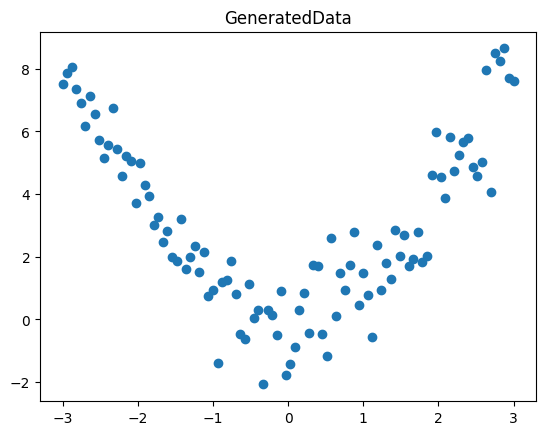

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def true_function(x):
    return x**2

x = np.linspace(-3, 3, 100)
y = true_function(x)+np.random.normal(0,1,100)

plt.scatter(x,y)
plt.title("GeneratedData")
plt.show()


In [2]:
def fir_model(x,y,degree):
    return np.polyfit(x, y, degree)

## Simulation Procedure 
We generate multiple datasets from the true function and fit polynomial models of different degrees to study the bias-variance tradeoff.

In [3]:
degrees = [1,2,5,10]
simulations = 100

x_test = np.linspace(-3, 3, 10)
true_y = true_function(x_test)

results = {}

for d in degrees:
    predictions = []
    for i in range(simulations):
        
        y_sample = true_function(x) + np.random.normal(0,1,100)
        coeffs = np.polyfit(x, y_sample, d)
        y_pred = np.polyval(coeffs, x_test)

        predictions.append(y_pred)

    results[d] = np.array(predictions)     


In [4]:
bias_list = []
variance_list = []

for d in degrees:
    preds = results[d]

    mean_pred = np.mean(preds, axis=0)

    bias = np.mean((mean_pred - true_y)**2)
    variance = np.mean(np.var(preds, axis=0))

    bias_list.append(bias)
    variance_list.append(variance)
    

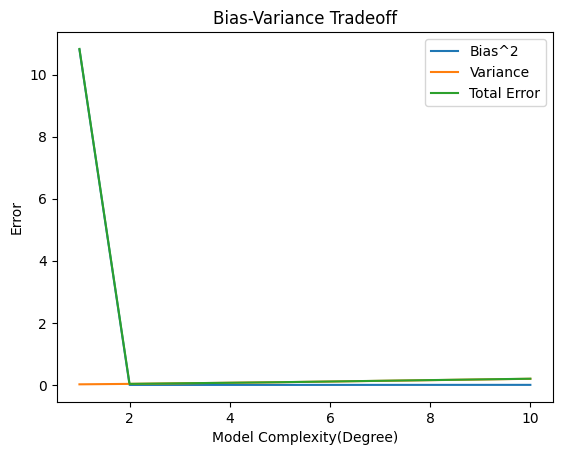

In [5]:
plt.plot(degrees, bias_list, label="Bias^2")
plt.plot(degrees, variance_list, label="Variance")

total_error = np.array(bias_list)+ np.array(variance_list)
plt.plot(degrees, total_error,label="Total Error")

plt.xlabel("Model Complexity(Degree)")
plt.ylabel("Error")
plt.legend()
plt.title("Bias-Variance Tradeoff")
plt.show()

## Bias-Variance Tradeoff
- As model complexity increases, bias decreases
- Variance increases with complexity
- There is a tradeoff between bias and variance

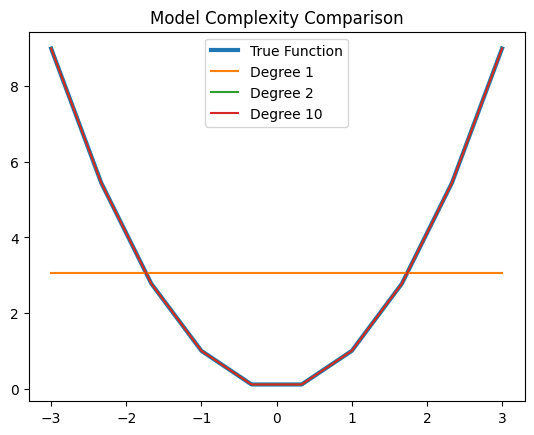

In [6]:
plt.plot(x_test, true_y, label="True Function", linewidth=3)
for d in [1,2,10]:
    coeffs = np.polyfit(x,true_function(x),d)
    y_pred = np.polyval(coeffs, x_test)
    plt.plot(x_test, y_pred, label=f"Degree {d}")

plt.legend()
plt.title("Model Complexity Comparison")
plt.show()

## Interpretation 
The results clearly illustrate the bias-variance tradeoff:
- Low-degree models (degree 1) underfit the data, resulting in high bias and low variance.
- Moderate-degree models (degree 2 or 5) achieve a good balance, minimizing total error.
- High-degree models (degree 10) overfit the data, resulting in low bias but high variance.

Thus, increasing model complexity reduces bias but increases variance. The optimal model is the one that balances both to minimize prediction error.

In [7]:
import pandas as pd
df = pd.DataFrame({
    "Degree": degrees,
    "Bias^2": bias_list,
    "Variance": variance_list})
df

,Degree,Bias^2,Variance
0,1,10.804730,0.019547
1,2,0.000504,0.033879
2,5,0.000985,0.087322
3,10,0.002328,0.198045


## Conclusion
This project demonstrates the fundamental concepts of the bias-variance tradeoff using simulation. It highlights the importance of selecting an appropriate model complexity to achieve optimal predictive performance.